In [1]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt
from itertools import islice
import json

from cryo_sbi.wpa_simulator.cryo_em_simulator import cryo_em_simulator
from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader

In [24]:
##models
side_lengths = torch.linspace(0, 50, 100)

models = []
for side_length in side_lengths:
    model = [
        [side_length, -side_length, side_length, -side_length],
        [side_length, side_length, -side_length, -side_length],
        [0.0, 0.0, 0.0, 0.0],
    ]
    models.append(model)
models = torch.tensor(models)

# substract of center of mass
for i in range(100):
    models[i] = models[i] - models[i].mean(dim=1, keepdim=True)
torch.save(models, "models.pt")

In [25]:
models.shape

torch.Size([100, 3, 4])

In [26]:
#models.to('cuda')
#images.to('cuda')

In [27]:
##images
simulator = CryoEmSimulator(
    "../simulation_parameters.json"
)  # creating simulator with simulation parameters

images, parameters = simulator.simulate(
    num_sim=100, return_parameters=True
)  # simulating images and save parameters
side_length = parameters[0]  # extracting side_length from parameters
snr = parameters[-1]  # extracting snr from parameters

In [13]:
estimator = est_utils.load_estimator(
    "../training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "../tutorial_estimator_2.pt",
    device="cpu",
)

In [14]:
device="cpu"
simulation_batch_size = 1
n_workers = 4
image_config = json.load(open('../simulation_parameters.json'))
train_config = json.load(open('../training_parameters_nle.json'))
image_prior = get_image_priors(len(models) - 1, image_config, device="cpu")
prior_loader = PriorLoader(image_prior, batch_size=simulation_batch_size, num_workers=n_workers)
num_pixels = torch.tensor(image_config["N_PIXELS"], dtype=torch.float32, device=device)
pixel_size = torch.tensor(image_config["PIXEL_SIZE"], dtype=torch.float32, device=device)

In [115]:
estimator.eval()
log_probs_list = []

with torch.no_grad():
    for parameters in islice(prior_loader, 100):
        (indices,quaternions,res,shift,defocus,b_factor,amp,snr,) = parameters
        images = cryo_em_simulator(models,
                indices.to(device, non_blocking=True),
                quaternions.to(device, non_blocking=True),
                res.to(device, non_blocking=True),
                shift.to(device, non_blocking=True),
                defocus.to(device, non_blocking=True),
                b_factor.to(device, non_blocking=True),
                amp.to(device, non_blocking=True),
                snr.to(device, non_blocking=True),
                num_pixels,
                pixel_size,
            )
        for _indices, _images in zip(
            indices.split(train_config["BATCH_SIZE"]),
            images.split(train_config["BATCH_SIZE"]),
        ):  
            
            models_selected = models[_indices.round().long().flatten()]
            models_selected = models_selected.transpose(1, 2)
            #print(_images.shape)
            #print(models_selected.shape)
            

            log_prob_batch = estimator.forward(_images, models_selected)
            log_probs_list.append(log_prob_batch)

In [119]:
print(np.shape(log_probs_list))
print(np.shape(log_probs_list)[0])

(500, 32)
500


In [33]:
##equivalent to above subtle difference in forward -> estomator.flow() then posterior.log_prob()
estimator.eval()
log_probs_list = []

with torch.no_grad():
    for parameters in islice(prior_loader, 100):
        (indices,quaternions,res,shift,defocus,b_factor,amp,snr,) = parameters
        images = cryo_em_simulator(models,
                indices.to(device, non_blocking=True),
                quaternions.to(device, non_blocking=True),
                res.to(device, non_blocking=True),
                shift.to(device, non_blocking=True),
                defocus.to(device, non_blocking=True),
                b_factor.to(device, non_blocking=True),
                amp.to(device, non_blocking=True),
                snr.to(device, non_blocking=True),
                num_pixels,
                pixel_size,
            )
        for _indices, _images in zip(
            indices.split(train_config["BATCH_SIZE"]),
            images.split(train_config["BATCH_SIZE"]),
        ):  
            
            models_selected = models[_indices.round().long().flatten()]
            models_selected = models_selected.transpose(1, 2)
            
            posterior = estimator.flow(models_selected.to(device))
            log_probs_list.append(posterior.log_prob(estimator.embedding_2(_images)))

In [120]:
import torch
from itertools import islice

estimator.eval()
all_log_probs = []

with torch.no_grad():
    for parameters in islice(prior_loader, 100):  # take 100 batches
        indices, quaternions, res, shift, defocus, b_factor, amp, snr = parameters
        
        # generate images
        images = cryo_em_simulator(
            models,
            indices.to(device, non_blocking=True),
            quaternions.to(device, non_blocking=True),
            res.to(device, non_blocking=True),
            shift.to(device, non_blocking=True),
            defocus.to(device, non_blocking=True),
            b_factor.to(device, non_blocking=True),
            amp.to(device, non_blocking=True),
            snr.to(device, non_blocking=True),
            num_pixels,
            pixel_size,
        )
        
        # optionally split batches if needed
        for _indices, _images in zip(
            indices.split(train_config["BATCH_SIZE"]),
            images.split(train_config["BATCH_SIZE"])
        ):
            # select models per batch
            models_selected = models[_indices.round().long().flatten()]  # shape [B,3,4]
            models_selected = models_selected.transpose(1, 2)           # if needed by forward

            # compute log-probabilities per image
            log_prob_batch = estimator.forward(_images, models_selected)  # shape [B]
            
            # append to list
            all_log_probs.append(log_prob_batch)

# flatten into a single vector for all images
all_log_probs = torch.cat(all_log_probs, dim=0)  # shape [num_images]

# compute average log-likelihood per image
avg_log_likelihood = all_log_probs.mean().item()
print("Average log-likelihood per image:", avg_log_likelihood)

# optional: histogram or summary of per-image log-likelihoods
print("Min:", all_log_probs.min().item(), "Max:", all_log_probs.max().item())


Average log-likelihood per image: 311.7757568359375
Min: 273.1259765625 Max: 314.552978515625


In [128]:
import torch
from itertools import islice

estimator.eval()
all_log_probs = []

with torch.no_grad():
    for parameters in islice(prior_loader, 100):  # take 100 batches
        indices, quaternions, res, shift, defocus, b_factor, amp, snr = parameters
        
        # generate all images in the batch
        images = cryo_em_simulator(
            models,
            indices.to(device, non_blocking=True),
            quaternions.to(device, non_blocking=True),
            res.to(device, non_blocking=True),
            shift.to(device, non_blocking=True),
            defocus.to(device, non_blocking=True),
            b_factor.to(device, non_blocking=True),
            amp.to(device, non_blocking=True),
            snr.to(device, non_blocking=True),
            num_pixels,
            pixel_size,
        )
        
        # select models corresponding to the batch
        models_selected = models[indices.round().long().flatten()]  # shape [B, 3, 4]
        models_selected = models_selected.transpose(1, 2)          # shape [B, 4, 3] if needed by forward

        # compute log-probabilities for the whole batch
        log_probs_batch = estimator.forward(images, models_selected)  # shape [B]
        
        # append to list
        all_log_probs.append(log_probs_batch)

# flatten into single vector
all_log_probs = torch.cat(all_log_probs, dim=0)  # shape [num_images]

# average log-likelihood per image
avg_log_likelihood = all_log_probs.mean().item()
print("Average log-likelihood per image:", avg_log_likelihood)

# optional: min/max or histogram to inspect variability
print("Min:", all_log_probs.min().item(), "Max:", all_log_probs.max().item())


Average log-likelihood per image: 311.6649475097656
Min: 272.5671081542969 Max: 314.29547119140625


In [129]:
np.shape(all_log_probs)

torch.Size([16000])

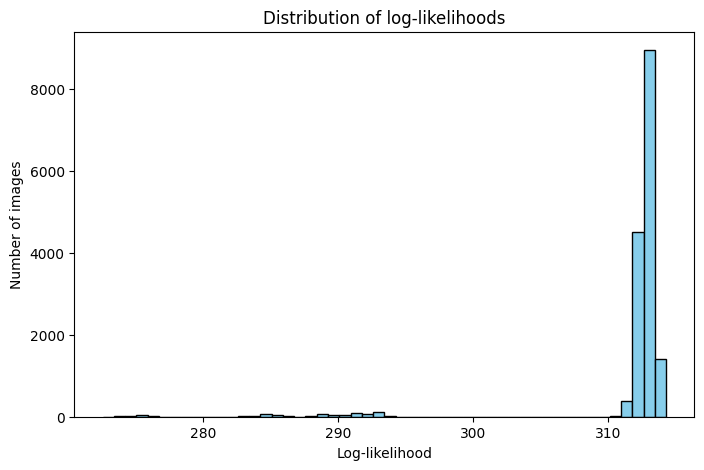

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(all_log_probs.cpu().numpy(), bins=50, color='skyblue', edgecolor='k')
plt.xlabel("Log-likelihood")
plt.ylabel("Number of images")
plt.title("Distribution of log-likelihoods")
plt.show()

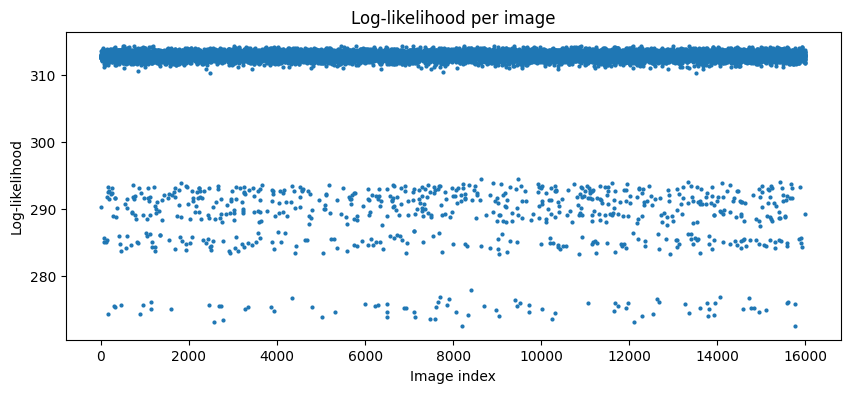

In [131]:
plt.figure(figsize=(10,4))
plt.plot(all_log_probs.cpu().numpy(), marker='o', linestyle='', markersize=2)
plt.xlabel("Image index")
plt.ylabel("Log-likelihood")
plt.title("Log-likelihood per image")
plt.show()

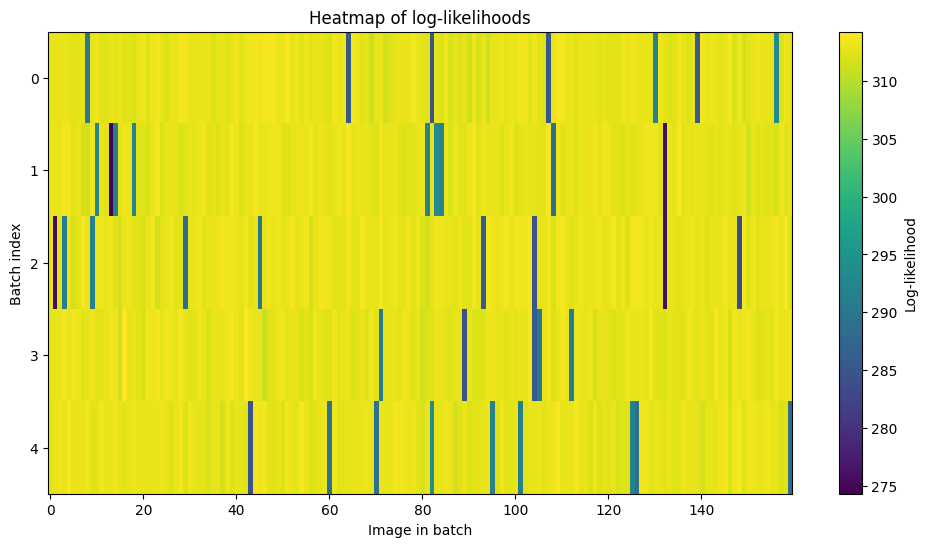

In [137]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Example: reshape all_log_probs to (num_batches, batch_size)
batch_size = simulation_batch_size
num_batches = len(all_log_probs) // batch_size
log_probs_array = all_log_probs[:num_batches*batch_size].view(num_batches, batch_size).cpu().numpy()

plt.figure(figsize=(12, 6))
plt.imshow(log_probs_array[:5], aspect='auto', cmap='viridis')
plt.colorbar(label='Log-likelihood')
plt.xlabel("Image in batch")
plt.ylabel("Batch index")
plt.title("Heatmap of log-likelihoods")
plt.show()


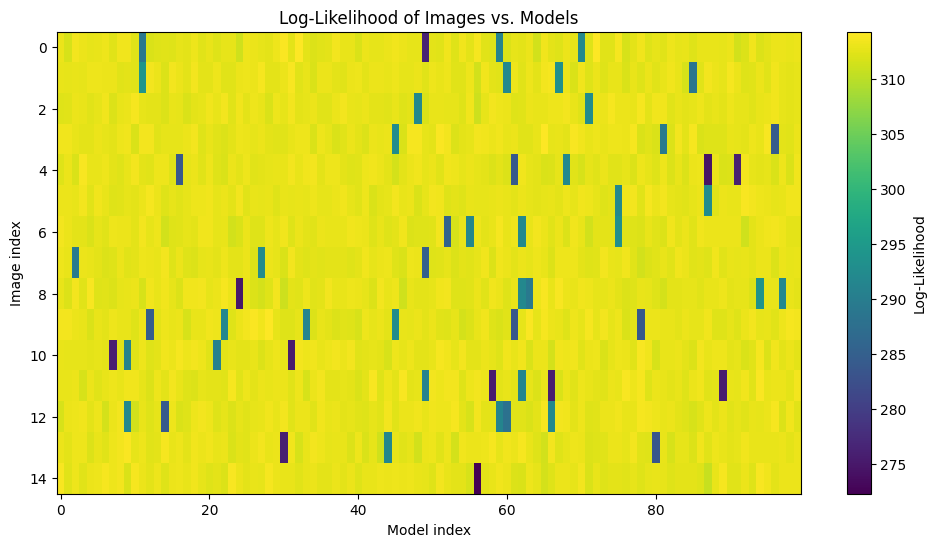

In [140]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Concatenate all log-prob batches into a single vector
log_probs_tensor = torch.cat(log_probs_list)  # shape [N_total_images]

# If you have N_total_images and N_models, you can reshape into a heatmap
# For demonstration, let's assume images correspond to rows and models to columns
N_total_images = log_probs_tensor.shape[0]
N_models = models.shape[0]

# If number of images matches number of models exactly, you can reshape
# Otherwise, you might need padding or just plot the raw vector
heatmap_data = log_probs_tensor.view(-1, N_models).cpu().numpy()  # shape [num_image_groups, N_models]

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data[:15], aspect='auto', cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.xlabel('Model index')
plt.ylabel('Image index')
plt.title('Log-Likelihood of Images vs. Models')
plt.show()


In [24]:
np.save('log_prob.npy',log_probs_list)

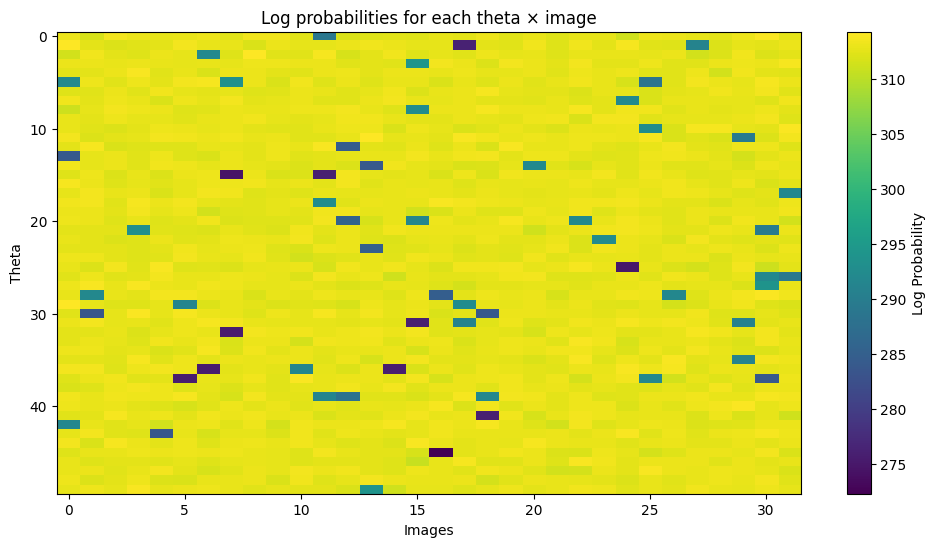

In [117]:
plt.figure(figsize=(12, 6))
plt.imshow(log_probs_list[:50], aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

In [15]:
import torch
import matplotlib.pyplot as plt

# Assume all images are generated and stacked in a single tensor
# images_all: [N_images, channels, height, width]
# models_all: [N_models, theta_dim] (e.g., 100x3x4)

# For demonstration, let's create images_all by generating all images at once
images_list = []
thetas_list = []

for parameters in prior_loader:  # iterate over your prior loader
    (indices, quaternions, res, shift, defocus, b_factor, amp, snr) = parameters
    images = cryo_em_simulator(
        models,
        indices.to(device),
        quaternions.to(device),
        res.to(device),
        shift.to(device),
        defocus.to(device),
        b_factor.to(device),
        amp.to(device),
        snr.to(device),
        num_pixels,
        pixel_size
    )
    images_list.append(images)
    thetas_list.append(models[indices.round().long().flatten()])

# Concatenate everything
images_all = torch.cat(images_list, dim=0)          # shape: [N_total_images, C, H, W]
thetas_all = torch.cat(thetas_list, dim=0)          # shape: [N_total_images, theta_dim]



KeyboardInterrupt: 

In [21]:
#images_all = torch.cat(images, dim=0)          # shape: [N_total_images, C, H, W]
#thetas_all = torch.cat(thetas, dim=0) 
images.shape

torch.Size([100, 64, 64])

TypeError: Invalid shape (16000,) for image data

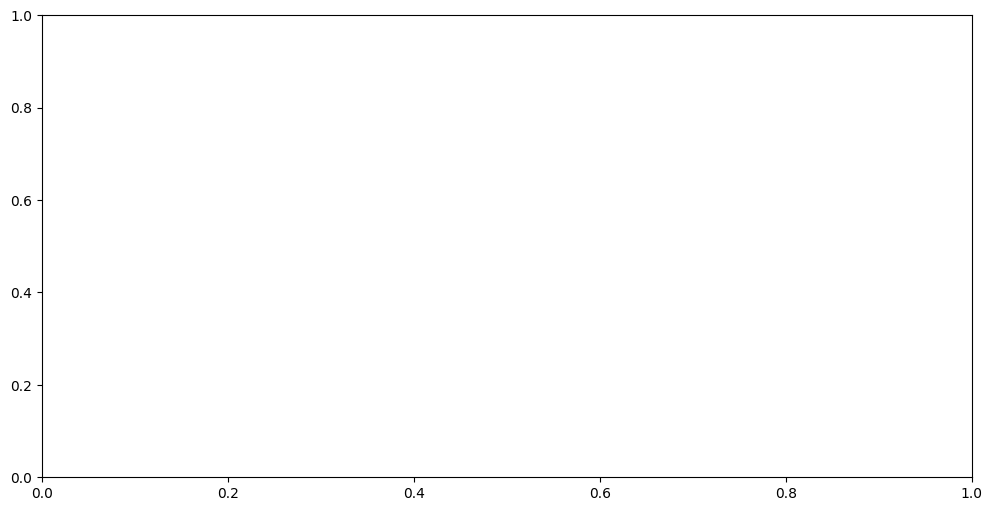

In [10]:
# Compute log-likelihoods in one shot
estimator.eval()
with torch.no_grad():
    log_probs_all = estimator.forward(images.to(device), thetas_all.to(device))

# Convert to numpy for plotting
log_probs_np = log_probs_all.cpu().numpy()

# Plot heatmap (images along rows, models along columns)
plt.figure(figsize=(12, 6))
plt.imshow(log_probs_np, aspect='auto', cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.xlabel('Model index')
plt.ylabel('Image index')
plt.title('Log-Likelihood of Images vs. Models (no batching)')
plt.show()

In [45]:
images.shape

torch.Size([5000, 64, 64])

In [47]:
log_probs_list = []

with torch.no_grad():
    # Loop over all precomputed images and corresponding models
    for _images, _models in zip(images, models):

        
        models_selected = models_selected.transpose(1, 2)

        # Compute log-probabilities using forward
        log_prob = estimator.forward(_images, _models)

        # Append to list
        log_probs_list.append(log_prob)

ValueError: not enough values to unpack (expected 3, got 2)

In [68]:
images.shape[0]

5000

In [78]:
log_probs = []
num_images = images.shape[0]  # 5000 in your case
num_models = models.shape[0]   # 100 in your case
image_batch_size = 32   # adjust for GPU memory
model_batch_size = 32   # adjust for GPU memory

with torch.no_grad():
    # Loop over models in batches
    for start_model in range(0, num_models, model_batch_size):
        end_model = min(start_model + model_batch_size, num_models)
        batch_models = models[start_model:end_model].to(device)  # shape (B_model, ...)

        # Transpose as in training
        batch_models = batch_models.transpose(1, 2)

        batch_log_probs = []

        # Loop over images in batches
        for start_img in range(0, num_images, image_batch_size):
            end_img = min(start_img + image_batch_size, num_images)
            batch_images = images[start_img:end_img].to(device)  # shape (B_img, ...)
            print(batch_images.shape)
            print(batch_models.shape)
            # Compute log-probs
            # forward expects images first, models second
            log_prob_batch = estimator.forward(batch_images,batch_models)
            # log_prob_batch shape: (B_img, B_model)
            batch_log_probs.append(log_prob_batch)

        # Concatenate over images
        batch_log_probs = torch.cat(batch_log_probs, dim=0)  # shape (num_images, B_model)
        log_probs.append(batch_log_probs)

# Concatenate over model batches if you split models
log_probs = torch.cat(log_probs, dim=1)  # shape (num_images, num_models)


torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32, 4, 3])
torch.Size([32, 64, 64])
torch.Size([32,

RuntimeError: Attempting to broadcast a dimension of length 32 at -1! Mismatching argument at index 1 had torch.Size([32]); but expected shape should be broadcastable to [8]

In [79]:
num_images = images.shape[0]
num_models = models.shape[0]

log_probs = torch.zeros(num_images, num_models, device=device)

with torch.no_grad():
    for i_model in range(num_models):
        theta = models[i_model].to(device).unsqueeze(0).transpose(1, 2)  # (1, 4, 3)
        for i_img in range(num_images):
            x = images[i_img].to(device).unsqueeze(0)  # (1, 64, 64)
            log_probs[i_img, i_model] = estimator.forward(x, theta)


In [80]:
log_probs.shape

torch.Size([5000, 100])

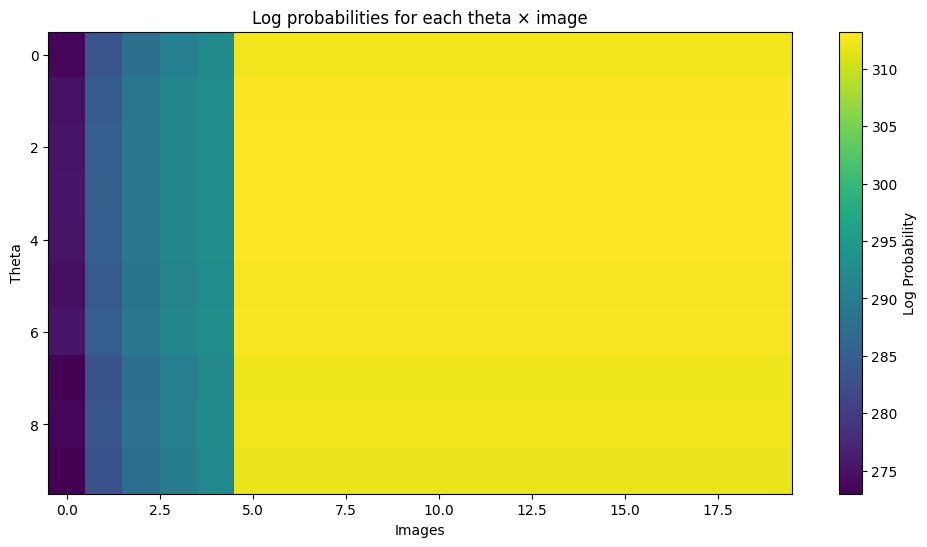

In [83]:
plt.figure(figsize=(12, 6))
plt.imshow(log_probs[:10, :20], aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

In [103]:
B_img = 32

for i_model in range(num_models):
    theta = models[i_model].to(device).unsqueeze(0).transpose(1, 2)

    for start in range(0, num_images, B_img):
        end = min(start + B_img, num_images)
        batch_x = images[start:end].to(device)
        log_prob_batch = estimator.forward(batch_x, theta)  # shape (B_img, 1) or (B_img,)
        log_probs[start:end, i_model] = log_prob_batch.squeeze()


In [105]:
print(log_probs.detach().numpy()[:10])

[[274.783   284.60202 288.73505 291.1651  292.73895 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 312.90466
  312.90466 312.90466 312.90466 312.90466 312.90466 312.90466 31

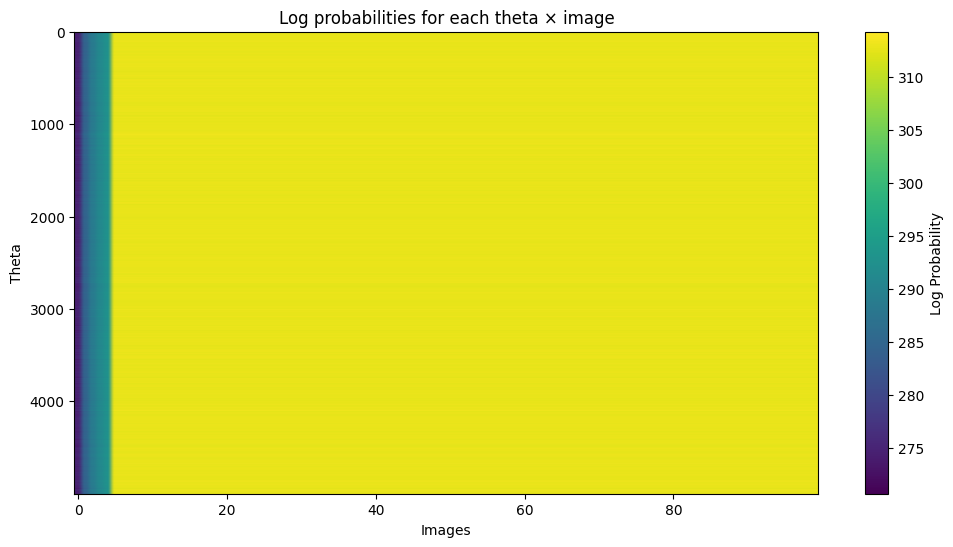

In [106]:
plt.figure(figsize=(12, 6))
plt.imshow(log_probs.detach().numpy(), aspect='auto', cmap='viridis')
plt.colorbar(label='Log Probability')
plt.xlabel('Images')
plt.ylabel('Theta')
plt.title('Log probabilities for each theta × image')
plt.show()

In [28]:
images = images_all

In [36]:
import torch
import matplotlib.pyplot as plt

# ---------------------------
# CONFIGURATION
# ---------------------------
device = 'cpu'

# images_all: [N_images, H, W] or [N_images, 1, H, W]
# models: [N_models, 4, 3]
# For example:
# images_all = torch.randn(5000, 64, 64)
# models = torch.randn(100, 4, 3)

# Make sure images have channel dimension
images_all = images_all.unsqueeze(1) if images_all.dim() == 3 else images_all

N_images = images_all.shape[0]
N_models = models.shape[0]

# ---------------------------
# EXPAND IMAGES AND MODELS
# ---------------------------
# Expand images: [N_images, N_models, C, H, W]
images_exp = images_all[:, None, :, :, :].expand(-1, N_models, -1, -1, -1)

# Expand models: [N_images, N_models, 4, 3]
models_exp = models[None, :, :, :].expand(N_images, -1, -1, -1)

# Flatten for forward pass: [N_images * N_models, ...]
#images_flat = images_exp.reshape(-1, images_exp.shape[2], images_exp.shape[3], images_exp.shape[4])
#models_flat = models_exp.reshape(-1, models_exp.shape[2], models_exp.shape[3])

# ---------------------------
# COMPUTE LOG-LIKELIHOODS
# ---------------------------
estimator.eval()
with torch.no_grad():
    log_probs_flat = estimator.forward(images_exp.to(device), models_exp.to(device))

# Reshape back to [N_images, N_models]
log_probs = log_probs_flat.reshape(N_images, N_models).cpu().numpy()

# ---------------------------
# PLOT HEATMAP
# ---------------------------
plt.figure(figsize=(12, 8))
plt.imshow(log_probs, aspect='auto', cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.xlabel('Model index')
plt.ylabel('Image index')
plt.title('Log-Likelihood of all images vs all models')
plt.show()


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [35]:
images_flat.shape

torch.Size([1600000, 1, 64, 64])

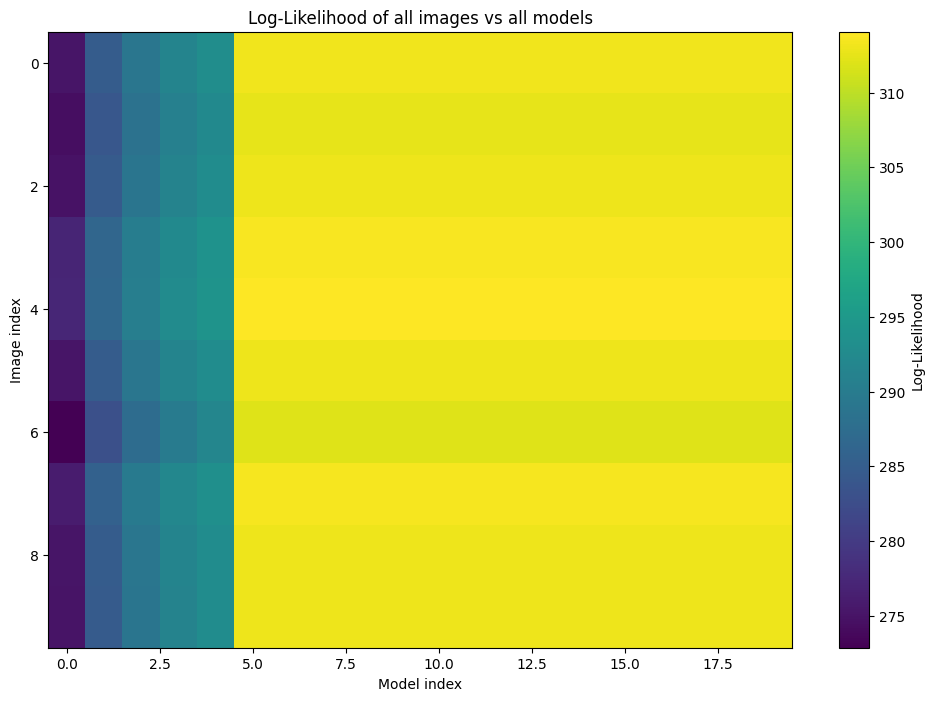

In [33]:
plt.figure(figsize=(12, 8))
plt.imshow(log_probs[:10,:20], aspect='auto', cmap='viridis')
plt.colorbar(label='Log-Likelihood')
plt.xlabel('Model index')
plt.ylabel('Image index')
plt.title('Log-Likelihood of all images vs all models')
plt.show()